In [ ]:
import scipy.io
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import requests

In [ ]:
url = "https://mason.gmu.edu/~lzhao9/pages/dataset_pages/datasets/spatial/traffic_dataset.mat"

response = requests.get(url)
with open("traffic_dataset.mat", "wb") as file:
    file.write(response.content)

data = scipy.io.loadmat("traffic_dataset.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tra_X_tr', 'tra_X_te', 'tra_Y_tr', 'tra_Y_te', 'tra_adj_mat'])


In [ ]:
def convert_to_dense(data_array):
    return np.array([mat.toarray() if isinstance(mat, csc_matrix) else mat for mat in data_array])

X_train = convert_to_dense(data['tra_X_tr'][0])  # Shape: (1261, 36, 48)
Y_train = convert_to_dense(data['tra_Y_tr'])     # Shape: (36, 1261)
X_test = convert_to_dense(data['tra_X_te'][0])   # Shape: (840, 36, 48)
Y_test = convert_to_dense(data['tra_Y_te'])      # Shape: (36, 840)

In [ ]:
Y_train = Y_train.T  # (1261, 36)
Y_test = Y_test.T    # (840, 36)

In [ ]:
scaler_x = MinMaxScaler()
X_train = scaler_x.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler_x.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

scaler_y = MinMaxScaler()
Y_train = scaler_y.fit_transform(Y_train)
Y_test = scaler_y.transform(Y_test)

In [ ]:
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(36, activation='sigmoid'))  # 36 outputs, one for each location

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_test, Y_test), verbose=1)

test_loss, test_mae = model.evaluate(X_test, Y_test)
print(f"Test Loss (MSE): {test_loss}")
print(f"Test MAE: {test_mae}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0693 - mae: 0.2208 - val_loss: 0.0362 - val_mae: 0.1539
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0269 - mae: 0.1328 - val_loss: 0.0196 - val_mae: 0.1085
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0139 - mae: 0.0925 - val_loss: 0.0130 - val_mae: 0.0860
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0086 - mae: 0.0708 - val_loss: 0.0108 - val_mae: 0.0765
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0070 - mae: 0.0620 - val_loss: 0.0101 - val_mae: 0.0733
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0065 - mae: 0.0595 - val_loss: 0.0092 - val_mae: 0.0700
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0060 - mae: 0.0568 - val_loss: 0.0090 - val_mae: 0.0687
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0055 - mae: 0.0537 - val_loss: 0.0085 - val_mae: 0.0660
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 

In [ ]:
predictions = model.predict(X_test)
predictions = scaler_y.inverse_transform(predictions)  # inverse transform to original scale
Y_test_orig = scaler_y.inverse_transform(Y_test)       # original scale for comparison

mse_score = mean_squared_error(Y_test_orig, predictions)
mae_score = mean_absolute_error(Y_test_orig, predictions)
print(f"Overall Test MSE: {mse_score}")
print(f"Overall Test MAE: {mae_score}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Overall Test MSE: 0.0027514869331165025
Overall Test MAE: 0.035973072484419964


In [ ]:
print("Predicted traffic flow for first 5 samples:", predictions[:5])
print("Actual traffic flow for first 5 samples:", scaler_y.inverse_transform(Y_test[:5]))

Predicted traffic flow for first 5 samples: [[0.40441605 0.6509709  0.36676598 0.38604882 0.28917304 0.27883923
  0.33235374 0.3389218  0.5997493  0.70993996 0.6518068  0.50062555
  0.62832105 0.6616714  0.77143294 0.28008398 0.2303494  0.22979437
  0.23277101 0.30411884 0.28418657 0.32975817 0.32034752 0.25882405
  0.17110461 0.7319878  0.3625799  0.18065566 0.26317132 0.77144796
  0.26054618 0.23329295 0.05983663 0.16848564 0.24159582 0.7659674 ]
 [0.3864445  0.68208426 0.36155877 0.37934926 0.34182906 0.31805262
  0.3930199  0.37138823 0.58107007 0.6772748  0.6354612  0.48204988
  0.5811103  0.652161   0.75992376 0.29747984 0.27648786 0.26019084
  0.2671527  0.35912517 0.34778893 0.37808758 0.3438179  0.295276
  0.19295788 0.82896674 0.34860602 0.1859808  0.276121   0.772848
  0.2986402  0.30342928 0.07220666 0.20024493 0.2631203  0.74748755]
 [0.37176472 0.68244374 0.3479004  0.37897182 0.38166153 0.3581153
  0.43182474 0.39393997 0.5816575  0.6768229  0.6288863  0.47854662
  0.563

In [ ]:
from sklearn.metrics import r2_score

predictions = model.predict(X_test)

predictions = scaler_y.inverse_transform(predictions)
Y_test_orig = scaler_y.inverse_transform(Y_test)

# Calculate R² score
r2 = r2_score(Y_test_orig, predictions)
print(f"R² Score: {r2:.4f}")
print(f"R² Score: {r2*100} %")


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R² Score: 0.8877
R² Score: 88.7654475340413 %


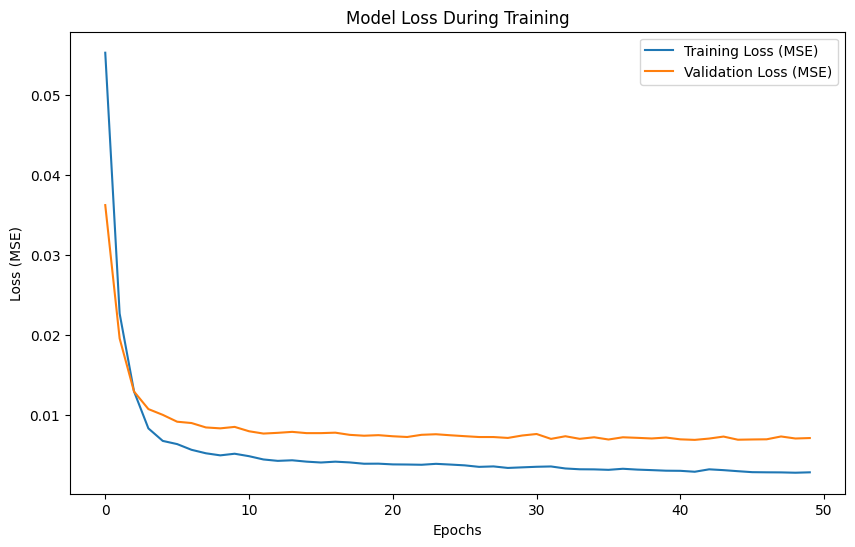

In [ ]:
# Plot 1: Loss vs. Epoch Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model Loss During Training')
plt.legend()
plt.savefig("loss_epochs.eps", format="eps", bbox_inches="tight")

plt.show()

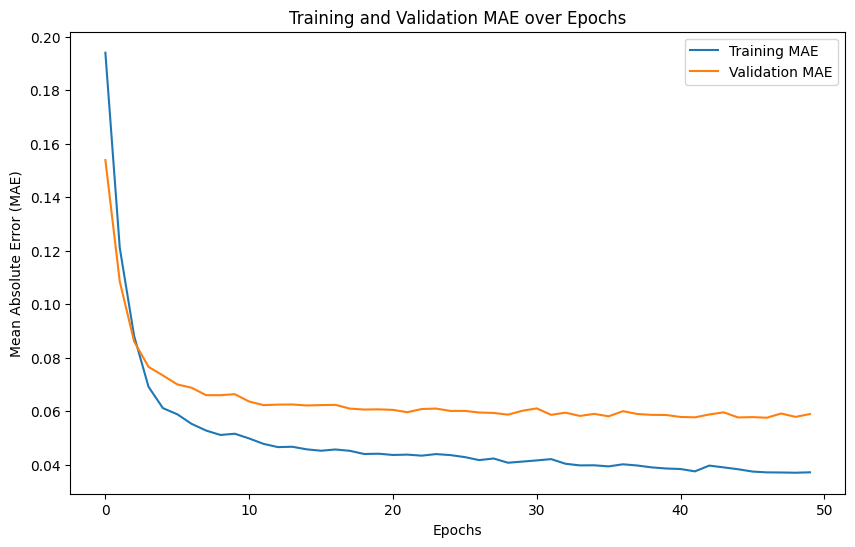

In [ ]:
# Plot 2: MAE vs. Epoch Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training and Validation MAE over Epochs')
plt.legend()
plt.savefig("mae_epochs.eps", format="eps", bbox_inches="tight")

plt.show()

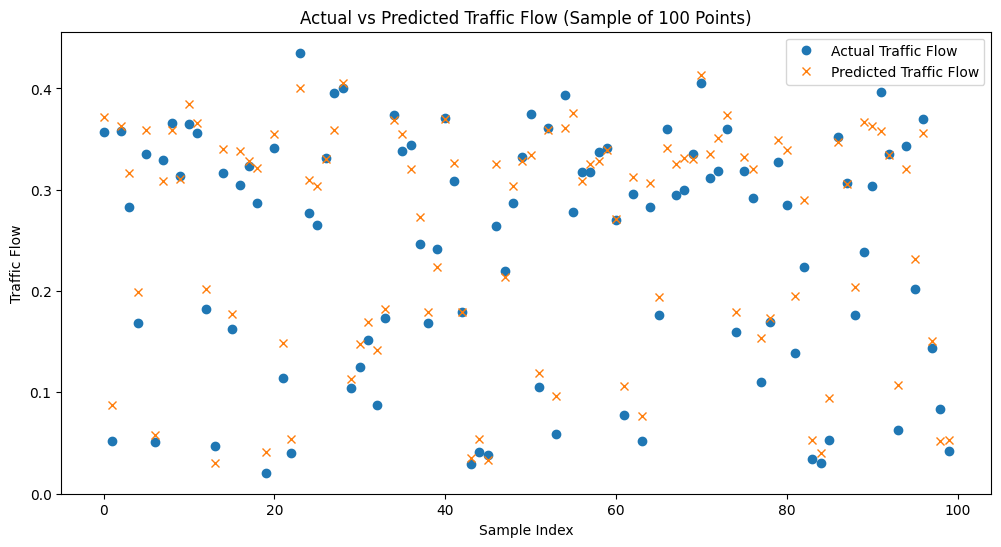

In [ ]:
# Plot 3: Actual vs Predicted Traffic Flow (sample of 100 points for clarity)
sample_idx = np.random.choice(Y_test_orig.shape[0], 100, replace=False)
plt.figure(figsize=(12, 6))
plt.plot(Y_test_orig[sample_idx, 0], label='Actual Traffic Flow', marker='o', linestyle='')
plt.plot(predictions[sample_idx, 0], label='Predicted Traffic Flow', marker='x', linestyle='')
plt.xlabel('Sample Index')
plt.ylabel('Traffic Flow')
plt.title('Actual vs Predicted Traffic Flow (Sample of 100 Points)')
plt.legend()
plt.savefig("actual_vs_predicted.eps", format="eps", bbox_inches="tight")

plt.show()

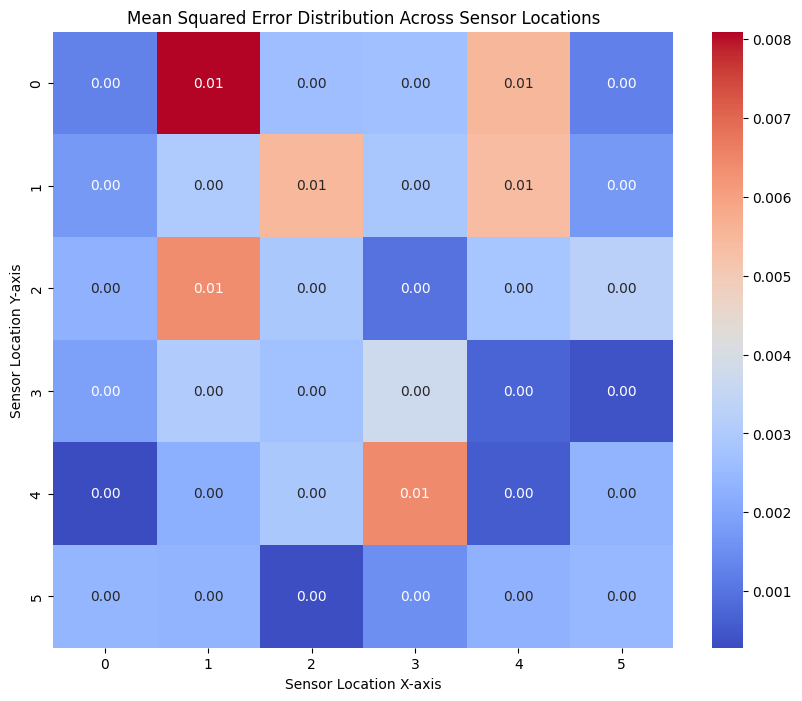

In [ ]:
# Plot 4: Error Distribution Heatmap
errors = Y_test_orig - predictions  # errors for each sensor location
mse_errors = np.mean(errors**2, axis=0)  # mean squared error for each location
plt.figure(figsize=(10, 8))
sns.heatmap(mse_errors.reshape(6, 6), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mean Squared Error Distribution Across Sensor Locations")
plt.xlabel("Sensor Location X-axis")
plt.ylabel("Sensor Location Y-axis")
plt.savefig("error_heatmap.eps", format="eps", bbox_inches="tight")

plt.show()

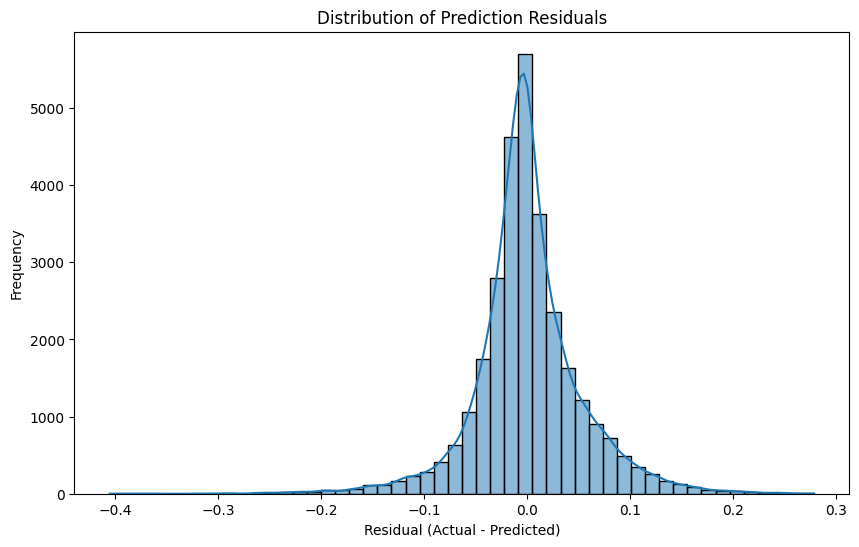

In [ ]:
# Plot 5: Residual Histogram
plt.figure(figsize=(10, 6))
sns.histplot(errors.flatten(), bins=50, kde=True)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")
plt.savefig("residual_histogram.eps", format="eps", bbox_inches="tight")
plt.show()